In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.append(str(root / "src"))

In [6]:
import math
import torch
import matplotlib.pyplot as plt

torch.manual_seed(3);

In [7]:
def rot2d(theta):
    c, s = math.cos(theta), math.sin(theta)
    return torch.tensor([[c, -s], [s, c]])

q = torch.randn(2)
k = torch.randn(2)
theta = 0.5

for m, n in [(3, 1), (7, 5), (12, 10), (5, 0)]:
    qm = rot2d(m * theta) @ q
    kn = rot2d(n * theta) @ k
    print(f"m={m:>2} n={n:>2}  m-n={m-n}  q·k = {qm @ kn:.4f}")


m= 3 n= 1  m-n=2  q·k = -0.4473
m= 7 n= 5  m-n=2  q·k = -0.4473
m=12 n=10  m-n=2  q·k = -0.4473
m= 5 n= 0  m-n=5  q·k = -0.2756


In [8]:
hs = 16
base = 10000
inv_freq = base ** (-torch.arange(0, hs, 2) / hs)  # [hs/2]
print(inv_freq)
print(2 * math.pi / inv_freq)   # wavelength: tokens per full revolution


tensor([1.0000e+00, 3.1623e-01, 1.0000e-01, 3.1623e-02, 1.0000e-02, 3.1623e-03,
        1.0000e-03, 3.1623e-04])
tensor([6.2832e+00, 1.9869e+01, 6.2832e+01, 1.9869e+02, 6.2832e+02, 1.9869e+03,
        6.2832e+03, 1.9869e+04])


In [9]:
T = 64
pos = torch.arange(T)
angles = pos[:, None] * inv_freq[None, :]   # [T, hs/2]
angles.shape


torch.Size([64, 8])

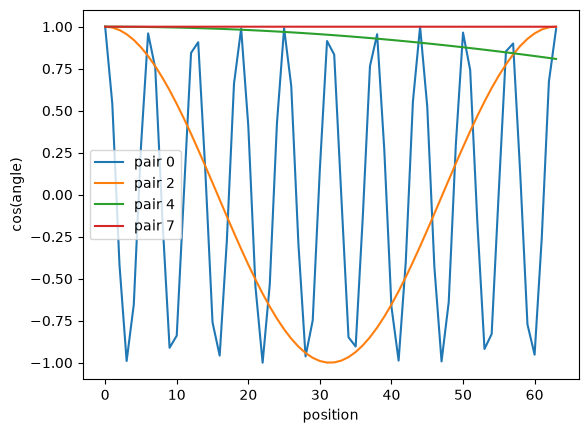

In [10]:
for i in [0, 2, 4, 7]:
    plt.plot(pos, angles[:, i].cos(), label=f"pair {i}")
plt.legend(); plt.xlabel("position"); plt.ylabel("cos(angle)");


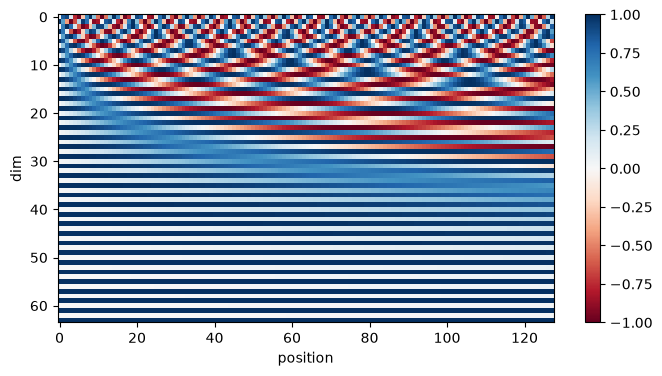

In [11]:
d = 64
T = 128
inv_freq = 10000 ** (-torch.arange(0, d, 2) / d)     # [d/2]
angles = torch.arange(T)[:, None] * inv_freq[None, :]  # [T, d/2]

pe = torch.empty(T, d)
pe[:, 0::2] = angles.sin()
pe[:, 1::2] = angles.cos()

plt.figure(figsize=(8, 4))
plt.imshow(pe.T, aspect="auto", cmap="RdBu")
plt.xlabel("position"); plt.ylabel("dim"); plt.colorbar();


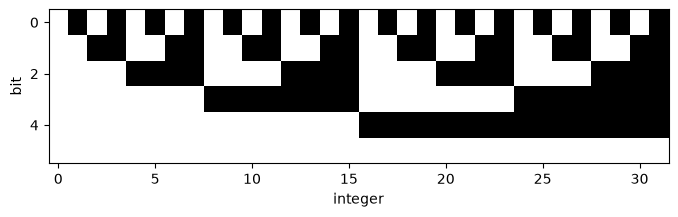

In [12]:
n_bits = 6
nums = torch.arange(32)
bits = (nums[:, None] >> torch.arange(n_bits)) & 1   # [32, 6]

plt.figure(figsize=(8, 2))
plt.imshow(bits.T, aspect="auto", cmap="gray_r")
plt.xlabel("integer"); plt.ylabel("bit");


In [13]:
i = 3                      # pick one pair
theta = inv_freq[i].item()
k = 5                      # shift by 5 positions

R = rot2d(k * theta)       # fixed matrix, no `pos` in it

for pos in [0, 10, 50, 100]:
    v_pos = pe[pos, 2*i : 2*i + 2]          # (sin, cos) at pos
    v_shifted = pe[pos + k, 2*i : 2*i + 2]  # (sin, cos) at pos+k
    print(pos, torch.allclose(R @ v_pos.flip(0), v_shifted.flip(0), atol=1e-5))


0 True
10 True
50 True
100 True


In [14]:
def apply_rope(x, base=10000):
    # x: [B, nh, T, hs]
    *_, T, hs = x.shape
    inv_freq = base ** (-torch.arange(0, hs, 2, device=x.device) / hs)  # [hs/2]
    pos = torch.arange(T, device=x.device)
    angles = pos[:, None] * inv_freq[None, :]   # [T, hs/2]
    cos, sin = angles.cos(), angles.sin()       # broadcast over [B, nh]
    x1 = x[..., 0::2]                           # [B, nh, T, hs/2]
    x2 = x[..., 1::2]
    out = torch.empty_like(x)
    out[..., 0::2] = x1 * cos - x2 * sin
    out[..., 1::2] = x1 * sin + x2 * cos
    return out

In [15]:
B, nh, T, hs = 2, 4, 32, 16
x = torch.randn(B, nh, T, hs)
r = apply_rope(x)

print(torch.allclose(r.norm(dim=-1), x.norm(dim=-1), atol=1e-5))  # norms preserved
print(torch.allclose(r[:, :, 0], x[:, :, 0]))                     # pos 0 untouched


True
True


In [16]:
qv = torch.randn(hs)
kv = torch.randn(hs)
q = qv.expand(1, 1, T, hs)   # same vector at all T positions
k = kv.expand(1, 1, T, hs)

scores = apply_rope(q) @ apply_rope(k).transpose(-2, -1)  # [1, 1, T, T]
s = scores[0, 0]

print(s[3, 1], s[7, 5], s[12, 10], s[31, 29])   # all m-n=2 → identical
print(s[5, 0], s[9, 4])                          # m-n=5 → identical, but different from above


tensor(-3.2497) tensor(-3.2497) tensor(-3.2497) tensor(-3.2497)
tensor(-4.3192) tensor(-4.3192)


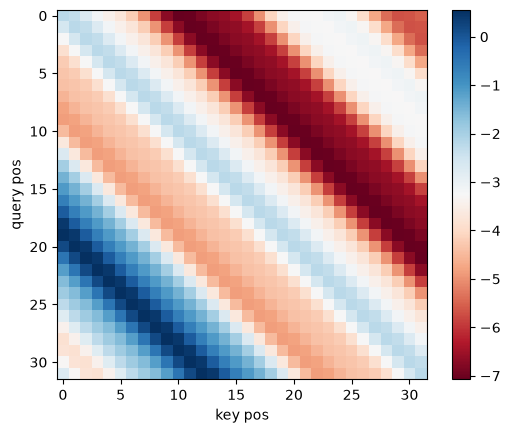

In [17]:
plt.imshow(s, cmap="RdBu")
plt.colorbar(); plt.xlabel("key pos"); plt.ylabel("query pos");


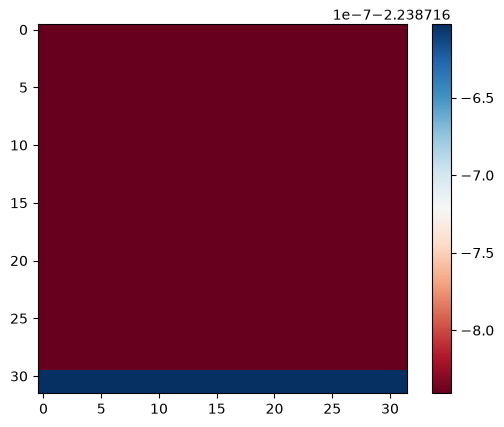

In [18]:
raw = q @ k.transpose(-2, -1)
plt.imshow(raw[0, 0], cmap="RdBu"); plt.colorbar();
